# EDA — LBNL Simulated RTU Dataset: Refrigerant Undercharge Fault

**Goal**: understand the data before touching any model. Looking at one
fault family (refrigerant undercharge, 10%/15%/20% severity) against the
unfaulted baseline, from the LBNL Simulated RTU dataset (NREL,
EnergyPlus-Modelica, 100-day period, 1-minute sampling, 24 sensor points).

Every hypothesis is stated before the code that tests it, and the result
is recorded - including when a check fails or surprises us.

## Data dictionary — what each column means

Standard building-automation naming: `OA`=outside air, `RA`=return air,
`SA`=supply air, `ZA`=zone air, `REFG`=refrigerant. Grouped by where each
sensor sits in the physical system, not alphabetically - this matters
more for actually understanding the data than a flat list would.

**Airside** (air moving through the building):
- `RTU_OA_FLOW` / `RTU_OA_HUM` / `RTU_OA_TEMP` - outside air: flow, humidity, temp
- `RTU_RA_FLOW` / `RTU_RA_HUM` / `RTU_RA_TEMP` - return air (coming back from the space)
- `RTU_SA_FLOW` / `RTU_SA_HUM` / `RTU_SA_TEMP` - supply air (conditioned air going into the space)
- `RTU_SA_FAN_WATT` - power drawn by the supply air fan
- `ZA_TEMP` / `ZA_HUM` - zone air: actual conditions in the occupied space
- `ZA_TEMP_SPT` - zone temperature **setpoint** (thermostat target, not a measurement)

**Refrigerant cycle** (suction -> compressor -> discharge -> condenser ->
expansion valve [not separately monitored] -> evaporator -> back to
suction):
- `RTU_REFG_SUCT_PRES` / `RTU_REFG_SUCT_TEMP` - refrigerant entering the compressor (low pressure)
- `RTU_REFG_DISC_PRES` / `RTU_REFG_DISC_TEMP` - refrigerant leaving the compressor (high pressure)
- `RTU_REFG_COND_PRES` / `RTU_REFG_COND_TEMP` - condenser, where hot gas gives up heat and condenses back to liquid
- `RTU_COMP_WATT` - power drawn by the compressor itself

**Capacity & status:**
- `RTU_SEN_CAPA` - *sensible* cooling capacity (the part that lowers temperature)
- `RTU_TOT_CAPA` - *total* cooling capacity (sensible + latent/humidity removal)
- `RTU_TOT_WATT` - total unit power draw (compressor + fans + controls)
- `RTU_STG_STA` - compressor stage status: confirmed empirically earlier in
  this notebook - `0.10` = off, `0.67` ≈ stage 1, `1.0` = stage 2

**Known caveat** (see Step 3): the three `_PRES` columns are documented
as Pascals but are miscalibrated by roughly 14-15x against real R410A
physics - use them as relative signals (ratios/deltas/z-scores), not
absolute physical values.

## 1 — load the data, check shape before assuming anything

First thing to verify in any dataset: does it match what the
documentation claims? Checking row/column counts and missing values
before computing a single statistic.

In [1]:
import pandas as pd

files = {
    "baseline": "../data/raw/RTU_sim_baseline.csv",
    "undercharge10": "../data/raw/RTU_sim_undercharge10.csv",
    "undercharge15": "../data/raw/RTU_sim_undercharge15.csv",
    "undercharge20": "../data/raw/RTU_sim_undercharge20.csv",
}

dfs = {label: pd.read_csv(fname) for label, fname in files.items()}

for label, df in dfs.items():
    print(f"{label}: shape={df.shape}, missing_values={df.isna().sum().sum()}")

baseline: shape=(143941, 25), missing_values=0
undercharge10: shape=(143941, 25), missing_values=0
undercharge15: shape=(143941, 25), missing_values=0
undercharge20: shape=(143941, 25), missing_values=0


In [2]:
import sys
from pathlib import Path

# ml/ is not an installed package (see ml/pyproject.toml: package-mode = false —
# deliberate, since ml/ isn't a deployed service). Notebooks live in ml/notebooks/,
# so add the ml/ root to sys.path to make `from src.features...` imports work
# consistently, the same way pytest's pythonpath = ["."] setting already does
# for the test suite.
ml_root = Path.cwd().parent
if str(ml_root) not in sys.path:
    sys.path.insert(0, str(ml_root))

from src.features.effect_size import cohens_d  # noqa: E402

**Result**: all four files are 143,941 rows × 25 columns, 0 missing
values. This is expected specifically for this *Simulated* dataset -
LBNL's docs note it runs identically regardless of time/day (no
occupied/unoccupied schedule), unlike the Experimental dataset, which
does have real gaps. Don't assume every LBNL file will be this clean.

## 2 — check column types, not just names

A number silently parsed as text is a common, easy-to-miss bug that
causes confusing errors much later. Checking dtypes now, before any
calculation depends on them.

In [3]:
df = dfs["baseline"]
df.dtypes

Datetime               object
RTU_COMP_WATT         float64
RTU_OA_FLOW           float64
RTU_OA_HUM            float64
RTU_OA_TEMP           float64
RTU_RA_FLOW           float64
RTU_RA_HUM            float64
RTU_RA_TEMP           float64
RTU_REFG_COND_PRES    float64
RTU_REFG_COND_TEMP    float64
RTU_REFG_DISC_PRES    float64
RTU_REFG_DISC_TEMP    float64
RTU_REFG_SUCT_PRES    float64
RTU_REFG_SUCT_TEMP    float64
RTU_SA_FAN_WATT       float64
RTU_SA_FLOW           float64
RTU_SA_HUM            float64
RTU_SA_TEMP           float64
RTU_SEN_CAPA          float64
RTU_STG_STA           float64
RTU_TOT_CAPA          float64
RTU_TOT_WATT          float64
ZA_HUM                float64
ZA_TEMP               float64
ZA_TEMP_SPT           float64
dtype: object

In [4]:
for _label, df in dfs.items():
    df["Datetime"] = pd.to_datetime(df["Datetime"])

df = dfs["baseline"]
print(df["Datetime"].dtype)
print("Range:", df["Datetime"].min(), "to", df["Datetime"].max())
print("Duration:", df["Datetime"].max() - df["Datetime"].min())

datetime64[ns]
Range: 2018-07-20 01:00:00 to 2018-10-28 00:00:00
Duration: 99 days 23:00:00


In [5]:
df.dtypes

Datetime              datetime64[ns]
RTU_COMP_WATT                float64
RTU_OA_FLOW                  float64
RTU_OA_HUM                   float64
RTU_OA_TEMP                  float64
RTU_RA_FLOW                  float64
RTU_RA_HUM                   float64
RTU_RA_TEMP                  float64
RTU_REFG_COND_PRES           float64
RTU_REFG_COND_TEMP           float64
RTU_REFG_DISC_PRES           float64
RTU_REFG_DISC_TEMP           float64
RTU_REFG_SUCT_PRES           float64
RTU_REFG_SUCT_TEMP           float64
RTU_SA_FAN_WATT              float64
RTU_SA_FLOW                  float64
RTU_SA_HUM                   float64
RTU_SA_TEMP                  float64
RTU_SEN_CAPA                 float64
RTU_STG_STA                  float64
RTU_TOT_CAPA                 float64
RTU_TOT_WATT                 float64
ZA_HUM                       float64
ZA_TEMP                      float64
ZA_TEMP_SPT                  float64
dtype: object

**Result**: `Datetime` came in as plain text, not a real date - expected,
since pandas never infers dates automatically. Fixed by explicitly
converting with `pd.to_datetime()`. Confirmed the corrected range spans
99 days 23 hours - matches LBNL's documented ~100-day period.

##  3 — do the refrigerant pressure columns match real physics?

The documentation labels `RTU_REFG_COND_PRES` as Pascals. Before trusting
that, sanity-check it against real R410A refrigerant saturation physics:
at a condensing temperature of ~26-28°C, real R410A should sit around
1,600-1,750 kPa. If our data's condenser pressure doesn't land anywhere
near that range at similar temperatures, that's a genuine red flag worth
chasing before building any feature on top of this column.

In [6]:
cond_temp_c = (df["RTU_REFG_COND_TEMP"] -  32) * 5/9
print("Condenser temp range (C):", cond_temp_c.min().round(1), "-", cond_temp_c.max().round(1))

print("\n Report condenser pressure, converted to kPa (dividing by 1000:)")
print((df["RTU_REFG_COND_PRES"] / 1000).describe())

Condenser temp range (C): 10.9 - 42.2

 Report condenser pressure, converted to kPa (dividing by 1000:)
count    143941.000000
mean      24409.509972
std        3450.815344
min       16180.200000
25%       22117.200000
50%       24736.676000
75%       26656.820000
max       37093.760000
Name: RTU_REFG_COND_PRES, dtype: float64


**Result**: condenser temperature varies naturally across the 100-day
period (10.9-42.2°C, day/night and seasonal variation) - this range
itself is expected, not a problem. At a representative mid-range
condensing temperature (~26-28°C), real R410A should saturate around
1,600-1,750 kPa. Our data shows a mean condenser pressure of 24,410 kPa
- roughly **14-15x higher** than real refrigerant physics would predict.

**Hypothesis rejected**: this column is not correctly calibrated in
absolute Pascals as documented. Likely a units/scaling artifact in the
source simulation or its documentation, not something resolvable from
outside the model itself.

**Action, not just a finding**: rather than discard the column, check
whether its *relative* structure (discharge vs. suction ratio, discharge
vs. condenser pressure) still behaves physically - that's what actually
matters for fault detection, which cares about deviation from a system's
own baseline, not absolute gauge-accurate values.

## 3b — does the *relative* pressure structure still make sense?

Absolute pressure looks miscalibrated, but that might not matter for us -
fault detection cares about deviation from a system's own baseline, not
matching a textbook gauge reading. Two physical facts to check instead:

1. Discharge pressure should always be higher than suction pressure
   (that's literally what compression does) - typically by a ratio of
   roughly 1.5-2x in a working refrigeration cycle.
2. Discharge pressure should sit very close to condenser pressure
   (within a percent or two) - there's only a short pipe run between the
   compressor's discharge port and the condenser inlet, so there's
   little room for these two to diverge.

In [7]:
RTU_REFG_PRES_RATION = (df["RTU_REFG_DISC_PRES"]/ df["RTU_REFG_SUCT_PRES"]).describe()
print(RTU_REFG_PRES_RATION)

disc_cond_pct_diff_full = (df["RTU_REFG_DISC_PRES"] - df["RTU_REFG_COND_PRES"]) / df["RTU_REFG_COND_PRES"] * 100
print(disc_cond_pct_diff_full.describe())

count    143941.000000
mean          1.614214
std           0.357259
min           0.983931
25%           1.374021
50%           1.718642
75%           1.867390
max           2.584772
dtype: float64
count    143941.000000
mean          0.902373
std           0.582498
min         -15.491286
25%           0.586092
50%           0.988556
75%           1.314489
max          17.076688
dtype: float64


In [8]:
extreme_rows = df[(disc_cond_pct_diff_full < -5) | (disc_cond_pct_diff_full > 5)]
print(f"Rows with more than 5% difference: {len(extreme_rows)} out of {len(df)}")
print(extreme_rows["RTU_STG_STA"].value_counts().head(5))

Rows with more than 5% difference: 23 out of 143941
RTU_STG_STA
0.6700    16
0.1000     3
1.0000     1
0.5275     1
0.6510     1
Name: count, dtype: int64


**Result**: the ratio's minimum (0.98, discharge briefly below suction)
is fully explained by `RTU_STG_STA = 0.10` (compressor off) - with no
active compression, pressures naturally equalize, so this isn't a data
problem. Checking the discharge-vs-condenser relationship more closely:
only 23 out of 143,941 rows (0.016%) show more than a 5% divergence,
mostly clustered during stage transitions (`RTU_STG_STA = 0.67`) rather
than spread across normal operation.

**Verdict**: the *relative* pressure structure is physically sound -
discharge consistently exceeds suction during active compression, and
tracks condenser pressure closely except for a tiny number of transient
edge cases. This confirms what Section 3 anticipated: absolute pressure
values are miscalibrated (~14-15x too high vs. real R410A physics), but
the relationships between pressure columns behave exactly as real
refrigeration physics predicts.

**Conclusion going forward**: use these pressure columns as *relative*
features (ratios, deltas, z-scores against this system's own baseline)
in feature engineering, not as absolute physical values. Fully
documented, not a blocker for moving forward.

## 4 — does refrigerant undercharge produce a real, monotonic fault signature?

Real refrigeration theory: undercharge starves the evaporator of liquid
refrigerant. Expected effects: higher suction temperature/pressure,
lower discharge pressure, and reduced cooling capacity - strengthening
as severity increases (10% -> 15% -> 20%).

Compressor-off periods would dilute this comparison (everything looks
idle regardless of fault), so we filter to `RTU_STG_STA >= 0.6` (stage 1
or 2 actively running) before comparing.

In [9]:
key_cols = ["RTU_REFG_SUCT_PRES", "RTU_REFG_DISC_PRES", "RTU_REFG_SUCT_TEMP", "RTU_TOT_CAPA"]

summary = pd.DataFrame({
    label: dfs[label][dfs[label]["RTU_STG_STA"] >= 0.6][key_cols].mean()
    for label in files
})
print(summary)

                        baseline  undercharge10  undercharge15  undercharge20
RTU_REFG_SUCT_PRES  1.473838e+07   1.478299e+07   1.489512e+07   1.501424e+07
RTU_REFG_DISC_PRES  2.597149e+07   2.592304e+07   2.577191e+07   2.550123e+07
RTU_REFG_SUCT_TEMP  5.364631e+01   5.385815e+01   5.430931e+01   5.487491e+01
RTU_TOT_CAPA        1.426396e+04   1.412715e+04   1.381829e+04   1.331877e+04


**Result**: all four metrics move **monotonically** with severity, in
the direction real refrigerant undercharge physics predicts:

| Metric | baseline -> 20% undercharge | Direction |
|---|---|---|
| Suction pressure | 14.74M -> 15.01M | up (relative signal only - see Step 3) |
| Discharge pressure | 25.97M -> 25.50M | down |
| Suction temperature | 53.6 -> 54.9 | up |
| **Total cooling capacity** | 14,264 -> 13,319 | down, **~6.6%** - strongest signal |

Capacity shows by far the cleanest, largest separation - a starved
evaporator moves less refrigerant, directly reducing how much heat the
system can remove. This makes it the priority feature for the classifier,
ahead of the subtler pressure shifts.

## 5 — visualize the separation, don't just trust the means

A mean difference can hide heavy overlap between distributions. Plotting
RTU_TOT_CAPA (our strongest signal) across all four severities to see
whether these groups actually separate, or just nudge apart slightly.

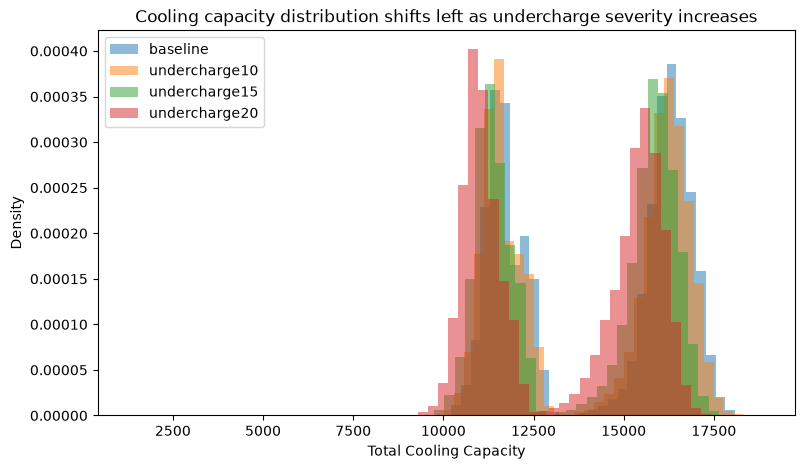

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for label in files:
    subset = dfs[label][dfs[label]["RTU_STG_STA"] >= 0.6]
    ax.hist(subset["RTU_TOT_CAPA"], bins=60, alpha=0.5, label=label, density=True)
ax.set_xlabel("Total Cooling Capacity")
ax.set_ylabel("Density")
ax.set_title("Cooling capacity distribution shifts left as undercharge severity increases")
ax.legend()
plt.show()

## 5b — separate compressor stage from fault severity

The two humps in the previous plot are stage 1 (partial capacity) vs.
stage 2 (full capacity) operation - a real operational difference,
unrelated to fault severity. Comparing fault severity within each stage
separately removes this confound and shows the fault's true effect size.

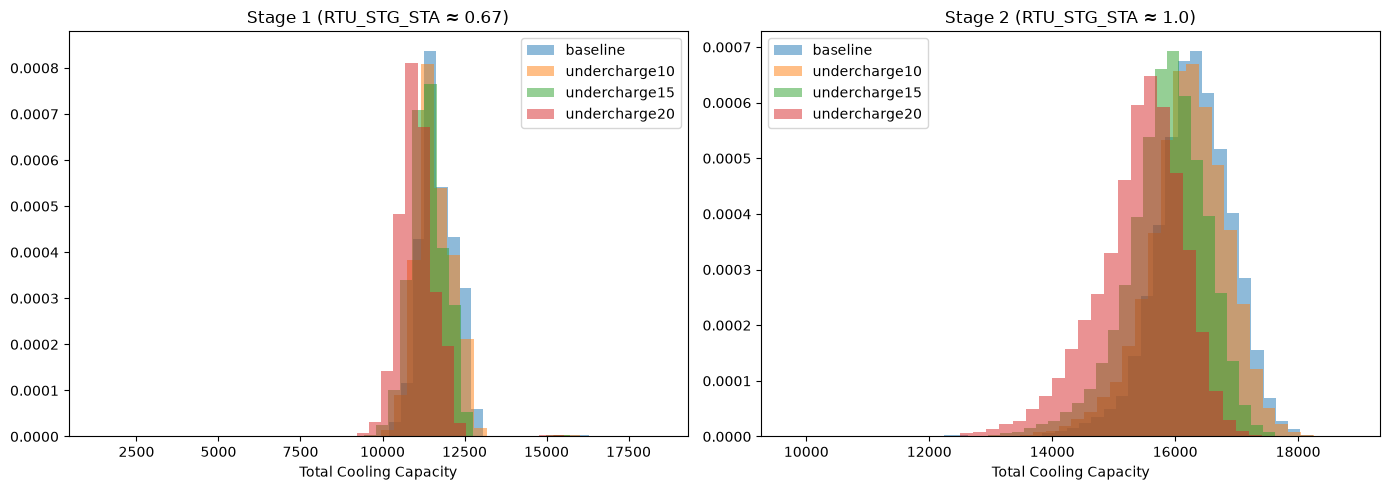

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stage_label, stage_filter in [
    (axes[0], "Stage 1 (RTU_STG_STA ≈ 0.67)", lambda d: (d["RTU_STG_STA"] > 0.6) & (d["RTU_STG_STA"] < 0.9)),
    (axes[1], "Stage 2 (RTU_STG_STA ≈ 1.0)", lambda d: d["RTU_STG_STA"] >= 0.9),
]:
    for label in files:
        subset = dfs[label][stage_filter(dfs[label])]
        ax.hist(subset["RTU_TOT_CAPA"], bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(stage_label)
    ax.set_xlabel("Total Cooling Capacity")
    ax.legend()

plt.tight_layout()
plt.show()

##  5c — why does real overlap persist even though the mean shift is real?

The mean shift in RTU_TOT_CAPA (baseline -> 20% undercharge) is only
~6.6%. If the natural minute-to-minute variance *within* a single
condition (ambient temp changes, capacity modulation, etc.) is larger
than that 6.6% shift, individual raw readings will overlap heavily even
though the underlying fault effect is real and monotonic. Checking the
actual numbers, not just eyeballing the plot.

In [12]:
stage2_baseline = dfs["baseline"][dfs["baseline"]["RTU_STG_STA"] >= 0.9]["RTU_TOT_CAPA"]
stage2_uc20 = dfs["undercharge20"][dfs["undercharge20"]["RTU_STG_STA"] >= 0.9]["RTU_TOT_CAPA"]

mean_shift = stage2_baseline.mean() - stage2_uc20.mean()
baseline_std = stage2_baseline.std()

print(f"Mean shift (baseline - undercharge20): {mean_shift:.1f}")
print(f"Baseline's own natural std deviation:   {baseline_std:.1f}")
print(f"Ratio (std / mean_shift):                {baseline_std / mean_shift:.2f}")

Mean shift (baseline - undercharge20): 902.8
Baseline's own natural std deviation:   628.0
Ratio (std / mean_shift):                0.70


## 5d — correcting the prediction, and what the numbers actually mean

Earlier prediction was wrong: the mean shift (902.8) is *larger* than
the baseline's own std deviation (628.0), not smaller. This is a
textbook "Cohen's d" effect size calculation - shift divided by std:

902.8 / 628.0 ≈ 1.44

By conventional statistics, d > 0.8 is considered a "large" effect - so
this fault's signal is genuinely strong, not weak. But even a large
effect size still produces real visual overlap in a histogram: two
normal distributions with d ≈ 1.4 still share roughly 30-35% of their
area. That reconciles what we saw in the plot (~60% overlap by eye) with
a mean shift that's actually statistically substantial.

**The real implication**: a single instantaneous reading is a noisy
version of a real signal - the fault genuinely shifts the average, but
minute-to-minute variation (ambient conditions, capacity modulation)
adds enough noise that individual points still overlap. This is exactly
why real fault-detection systems don't classify off one raw reading -
they use a **rolling/smoothed average** first. Averaging N readings
together shrinks the effective noise by roughly √N (a basic statistical
fact), which is precisely what an EWMA-based feature will give us in the
next step: not a new signal, but a cleaner view of the same real signal
we just confirmed exists.

##  6 — EWMA: turning a noisy-but-real signal into a usable feature

We just proved: RTU_TOT_CAPA carries a real fault signal (effect size
d≈1.44), but individual readings are noisy enough to visually overlap.
The fix is smoothing - specifically an **Exponentially Weighted Moving
Average (EWMA)**, not a simple moving average, and here's why the
distinction matters:

A simple moving average needs a fixed window of N past points stored
and weights every one of them equally - point 1 and point 29 in a
30-point window count the same. EWMA instead weights every past point
with exponentially decaying importance:

    EWMA_t = alpha * x_t + (1 - alpha) * EWMA_(t-1)

Recent readings matter more, older readings fade out gradually rather
than dropping off a cliff at some arbitrary window edge - and it only
needs to remember one running value, not a whole window, which matters
for a real product doing this continuously per-asset rather than
replaying a fixed historical batch.

**Choosing the smoothing amount**: pandas' `.ewm()` lets you specify this
as `alpha`, `span`, or `halflife` - we'll use `span=30` (roughly a
30-minute half-weighted window, since our data is 1-minute sampled).
Reasoning: RTU thermal/mechanical dynamics don't meaningfully change
minute-to-minute - a real fault signature should persist over tens of
minutes of continuous operation, while much of the point-to-point noise
(ambient fluctuation, capacity modulation) resolves faster than that.
30 minutes is a reasonable starting point to test, not a guess we'll
leave unquestioned - we'll revisit it once we see the effect.

In [13]:
for _label, df_ in dfs.items():
    df_["capacity_ewma30"] = df_["RTU_TOT_CAPA"].ewm(span=30).mean()

# Re-run the same effect-size calculation as before, but on the smoothed feature
stage2_baseline_smooth = dfs["baseline"][dfs["baseline"]["RTU_STG_STA"] >= 0.9]["capacity_ewma30"]
stage2_uc20_smooth = dfs["undercharge20"][dfs["undercharge20"]["RTU_STG_STA"] >= 0.9]["capacity_ewma30"]

mean_shift_smooth = stage2_baseline_smooth.mean() - stage2_uc20_smooth.mean()
std_smooth = stage2_baseline_smooth.std()

print(f"RAW      -> mean shift: {mean_shift:.1f}, std: {baseline_std:.1f}, effect size: {mean_shift/baseline_std:.2f}")
print(f"EWMA(30) -> mean shift: {mean_shift_smooth:.1f}, std: {std_smooth:.1f}, effect size: {mean_shift_smooth/std_smooth:.2f}")

RAW      -> mean shift: 902.8, std: 628.0, effect size: 1.44
EWMA(30) -> mean shift: 499.5, std: 1498.0, effect size: 0.33


##  6b — why did EWMA make things WORSE, not better?

Prediction was wrong: EWMA(30)'s effect size (0.33) is far below raw
(1.44), and its std (1498) is more than double the raw std (628) -
smoothing should reduce variance, not inflate it. Something about how
we applied EWMA must be introducing new noise rather than removing it.

Leading suspect: `.ewm()` was applied across the ENTIRE continuous time
series, including every compressor on/off cycle. RTU_TOT_CAPA swings
from near-zero (off) to ~14,000+ (stage 2) throughout the day. A rolling
average computed straight through those transitions doesn't just smooth
noise - it blends fundamentally different operating regimes together.
When we then filter to "stage 2 only" moments, we're pulling out EWMA
values that are still partly "contaminated" by a recent off/stage-1
period, depending on how long ago the system last changed state. That's
a new source of variance that has nothing to do with the fault.

In [14]:
for _label, df_ in dfs.items():
    # Coarse operating state: off / stage1 / stage2 - collapses the many
    # near-continuous transition values into 3 buckets
    stage_bucket = pd.cut(df_["RTU_STG_STA"], bins=[-0.01, 0.3, 0.9, 1.01], labels=["off", "stage1", "stage2"])
    # A new "run id" that only increments when the bucket actually changes -
    # this lets us group by contiguous stretches of the same operating state
    run_id = (stage_bucket != stage_bucket.shift()).cumsum()
    df_["capacity_ewma30_segmented"] = (
        df_.groupby(run_id)["RTU_TOT_CAPA"].transform(lambda s: s.ewm(span=30).mean())
    )

stage2_baseline_seg = dfs["baseline"][dfs["baseline"]["RTU_STG_STA"] >= 0.9]["capacity_ewma30_segmented"]
stage2_uc20_seg = dfs["undercharge20"][dfs["undercharge20"]["RTU_STG_STA"] >= 0.9]["capacity_ewma30_segmented"]

mean_shift_seg = stage2_baseline_seg.mean() - stage2_uc20_seg.mean()
std_seg = stage2_baseline_seg.std()

print(f"RAW                -> mean shift: {mean_shift:.1f}, std: {baseline_std:.1f}, effect size: {mean_shift/baseline_std:.2f}")
print("EWMA(30) naive     -> mean shift: 499.5, std: 1498.0, effect size: 0.33")
print(f"EWMA(30) segmented -> mean shift: {mean_shift_seg:.1f}, std: {std_seg:.1f}, effect size: {mean_shift_seg/std_seg:.2f}")

RAW                -> mean shift: 902.8, std: 628.0, effect size: 1.44
EWMA(30) naive     -> mean shift: 499.5, std: 1498.0, effect size: 0.33
EWMA(30) segmented -> mean shift: 950.0, std: 599.2, effect size: 1.59


## 6c — confirmed: EWMA only helps when computed within same-state runs

| Approach | Mean shift | Std | Effect size |
|---|---|---|---|
| Raw | 902.8 | 628.0 | 1.44 |
| EWMA(30), naive (whole series) | 499.5 | 1498.0 | 0.33 - **worse** |
| EWMA(30), segmented by compressor state | 950.0 | 599.2 | **1.59 - best** |

**Confirmed**: naively smoothing across compressor on/off transitions
doesn't reduce noise - it manufactures new noise by blending genuinely
different operating regimes into one rolling average. Segmenting by
contiguous same-state runs first, then applying EWMA only within each
run, gives a real improvement over raw (1.59 vs. 1.44) - modest but
genuine, and exactly the kind of gain smoothing is supposed to provide.

**Lesson for feature engineering going forward**: any rolling/EWMA
feature on this data must respect `RTU_STG_STA` transitions - applying
it blindly across the full time series is a real bug, not a minor
detail, and would have silently produced a worse feature if we hadn't
checked the "why" instead of accepting a confusing number.

In [15]:
# same two series as Section 5c/6c: stage-2-only, baseline vs undercharge20
d_pooled = cohens_d(stage2_baseline, stage2_uc20)
d_pooled_smoothed = cohens_d(stage2_baseline_seg, stage2_uc20_seg)

print(f"Baseline-std method (as computed above): raw={mean_shift/baseline_std:.2f}, segmented-EWMA={mean_shift_seg/std_seg:.2f}")
print(f"Pooled-std method (cohens_d):             raw={d_pooled:.2f}, segmented-EWMA={d_pooled_smoothed:.2f}")

Baseline-std method (as computed above): raw=1.44, segmented-EWMA=1.59
Pooled-std method (cohens_d):             raw=1.33, segmented-EWMA=1.41


## 6d — reconciling with the standard pooled-std Cohen's d

| Method | Raw | Segmented EWMA |
|---|---|---|
| Baseline-std (Sections 5d/6/6c, as originally computed) | 1.44 | 1.59 |
| Pooled-std (`cohens_d()`, the convention used from notebook 03 onward) | **1.33** | **1.41** |

The pooled-std numbers are consistently lower (raw: -7.6%, segmented: -11.3%) — expected,
since undercharge20's own variance adds to the denominator under the pooled method but
not the baseline-only method, and if undercharge20 is at least as noisy as baseline
(plausible, given a fault condition could plausibly add its own variability), pooling
will always pull the denominator up and the effect size down somewhat.

**Both conventions agree on the qualitative conclusion** — undercharge's capacity signal
is a large effect (>0.8) under either method, and segmented EWMA still outperforms raw
smoothing under either method. The original Sections 5d/6/6c numbers (1.44, 1.59) are
left as-is above as the authentic record of that exploration; **1.33 and 1.41 (pooled)
are the numbers that should be cited going forward** for consistency with notebooks
03/04, which use the pooled `cohens_d()` throughout.

*(Note: undercharge's original d≈1.44 was computed with a baseline-std-only method;
the pooled-std equivalent, consistent with this notebook's `cohens_d()`, is d≈1.33 —
see notebook 01, Section 6d. Doesn't change the qualitative comparison here.)*